In [4]:
# ============================================================
# Nickel Nitrate Solution Density at 20 °C
# ============================================================
#
# Author: Le Tuan Anh
# Date: 2026-05-14
#
# This notebook loads density data for aqueous Ni(NO3)2 solutions,
# performs curve fitting, and plots the results.
#
# ------------------------------------------------------------
# Data source
# ------------------------------------------------------------
# Engineering Database:
# https://engdatabase.com/data/aqueous-solution-properties/nickelnitrate20
#
# Original reference cited by the website:
# Perry's Chemical Engineers' Handbook, 8th Edition,
# Table 2-66, page 2-149.
#
# ------------------------------------------------------------
# Why polynomial fitting?
# ------------------------------------------------------------
# Density of aqueous salt solutions generally changes smoothly
# and nonlinearly with concentration.
#
# A second-order polynomial is commonly used for empirical
# interpolation over moderate concentration ranges because:
#
#   1. It captures slight curvature in the data
#   2. It avoids overfitting
#   3. It remains numerically stable
#   4. It is easy to interpret and reproduce
#
# Fit equation:
#
#   density = a*x^2 + b*x + c
#
# where:
#   x = mass percent of Ni(NO3)2
#
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [5]:
# ------------------------------------------------------------
# Experimental data
# ------------------------------------------------------------

mass_percent = np.array([1, 2, 4, 8, 12, 16, 20, 30, 35])

density = np.array([
    1.0065,
    1.0150,
    1.0325,
    1.0688,
    1.1070,
    1.1480,
    1.1910,
    1.3110,
    1.3770
])


In [6]:
# ------------------------------------------------------------
# Define fitting function
# ------------------------------------------------------------

def quadratic_fit(x, a, b, c):
    """
    Second-order polynomial fit.
    
    density = a*x^2 + b*x + c
    """
    return a*x**2 + b*x + c

In [7]:
# ------------------------------------------------------------
# Perform curve fitting
# ------------------------------------------------------------

popt, pcov = curve_fit(quadratic_fit, mass_percent, density)

a, b, c = popt

# ------------------------------------------------------------
# Calculate fitted values
# ------------------------------------------------------------

x_fit = np.linspace(0, 36, 500)
y_fit = quadratic_fit(x_fit, a, b, c)

y_data_fit = quadratic_fit(mass_percent, a, b, c)

# ------------------------------------------------------------
# Goodness of fit (R^2)
# ------------------------------------------------------------

ss_res = np.sum((density - y_data_fit)**2)
ss_tot = np.sum((density - np.mean(density))**2)

r_squared = 1 - (ss_res / ss_tot)

# ------------------------------------------------------------
# Print fitting parameters
# ------------------------------------------------------------

print("================================================")
print("Quadratic Fit Parameters")
print("================================================")
print(f"a = {a:.8e}")
print(f"b = {b:.8e}")
print(f"c = {c:.8e}")
print("------------------------------------------------")
print(f"R^2 = {r_squared:.8f}")
print("================================================")

print("\nFit equation:")
print(f"density = ({a:.6e}) x^2 + ({b:.6e}) x + ({c:.6e})")

Quadratic Fit Parameters
a = 7.76050922e-05
b = 8.08766875e-03
c = 9.98665230e-01
------------------------------------------------
R^2 = 0.99999500

Fit equation:
density = (7.760509e-05) x^2 + (8.087669e-03) x + (9.986652e-01)


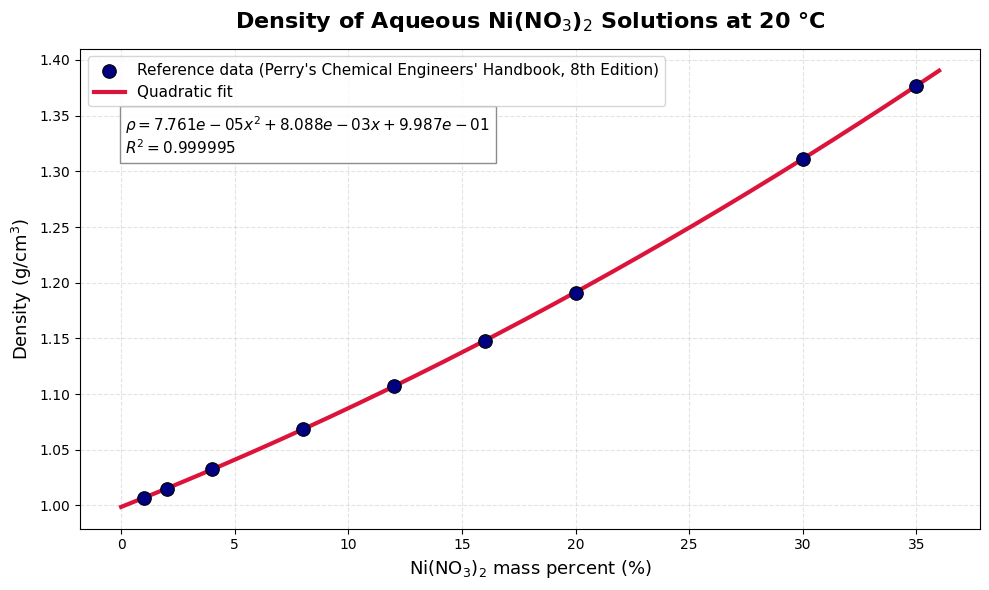

In [10]:
# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

# Experimental data
plt.scatter(
    mass_percent,
    density,
    s=95,
    color='navy',
    edgecolors='black',
    linewidths=0.8,
    label="Reference data (Perry's Chemical Engineers' Handbook, 8th Edition)",
    zorder=3
)

# Fitted curve
plt.plot(
    x_fit,
    y_fit,
    color='crimson',
    linewidth=3,
    label="Quadratic fit",
    zorder=2
)

# Labels
plt.xlabel(
    "Ni(NO$_3$)$_2$ mass percent (%)",
    fontsize=13
)

plt.ylabel(
    "Density (g/cm$^3$)",
    fontsize=13
)

# Title
plt.title(
    "Density of Aqueous Ni(NO$_3$)$_2$ Solutions at 20 °C",
    fontsize=16,
    pad=15,
    weight='bold'
)

# Grid
plt.grid(
    True,
    linestyle="--",
    alpha=0.35
)

# Legend
plt.legend(
    fontsize=11,
    frameon=True
)

# Equation text
eq_text = (
    f"$\\rho = {a:.3e}x^2 + {b:.3e}x + {c:.3e}$\n"
    f"$R^2 = {r_squared:.6f}$"
)

plt.text(
    0.05,
    0.78,
    eq_text,
    transform=plt.gca().transAxes,
    fontsize=11,
    bbox=dict(
        facecolor='white',
        edgecolor='gray',
        alpha=0.9
    )
)

# Improve layout
plt.tight_layout()

# Save high-resolution image
plt.savefig(
    "NiNO3_density_fit.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

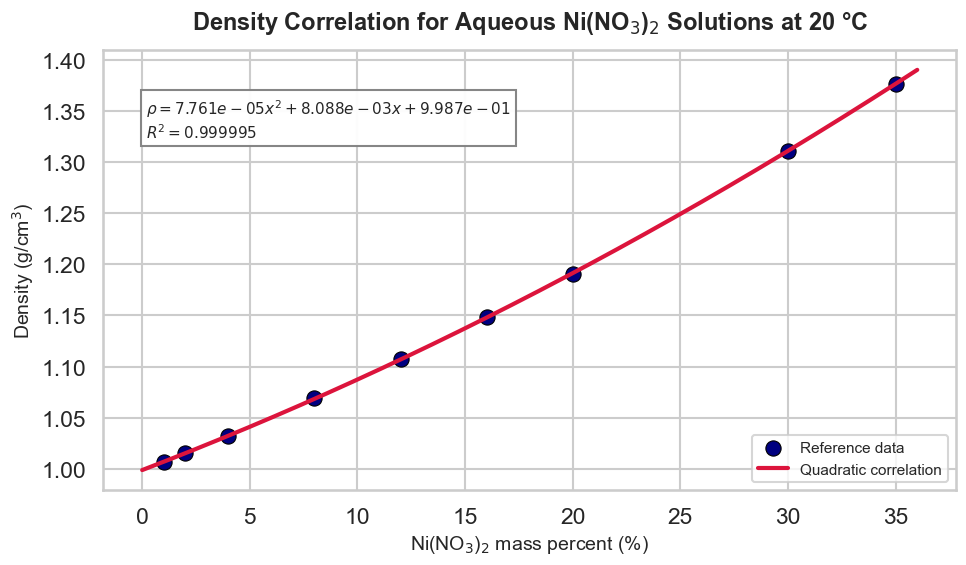

In [12]:
# ============================================================
# Alternative Plot using Seaborn
# ============================================================
#
# Seaborn provides:
# - cleaner default styles
# - smoother publication-quality appearance
# - improved typography and grid aesthetics
#
# ============================================================

import seaborn as sns

# ------------------------------------------------------------
# Seaborn style setup
# ------------------------------------------------------------

sns.set_theme(
    style="whitegrid",
    context="talk"
)

# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

# Scatter plot
sns.scatterplot(
    x=mass_percent,
    y=density,
    s=120,
    color="navy",
    edgecolor="black",
    linewidth=0.8,
    label="Reference data"
)

# Fitted curve
sns.lineplot(
    x=x_fit,
    y=y_fit,
    color="crimson",
    linewidth=3,
    label="Quadratic correlation"
)

# ------------------------------------------------------------
# Labels and title
# ------------------------------------------------------------

plt.xlabel(
    "Ni(NO$_3$)$_2$ mass percent (%)",
    fontsize=14
)

plt.ylabel(
    "Density (g/cm$^3$)",
    fontsize=14
)

plt.title(
    "Density Correlation for Aqueous Ni(NO$_3$)$_2$ Solutions at 20 °C",
    fontsize=17,
    weight='bold',
    pad=15
)

# ------------------------------------------------------------
# Equation box
# ------------------------------------------------------------

eq_text = (
    f"$\\rho = {a:.3e}x^2 + {b:.3e}x + {c:.3e}$\n"
    f"$R^2 = {r_squared:.6f}$"
)

plt.text(
    0.05,
    0.80,
    eq_text,
    transform=plt.gca().transAxes,
    fontsize=11,
    bbox=dict(
        facecolor='white',
        edgecolor='gray',
        alpha=0.95
    )
)

# ------------------------------------------------------------
# Legend
# ------------------------------------------------------------

plt.legend(
    frameon=True,
    fontsize=11
)

# ------------------------------------------------------------
# Improve layout
# ------------------------------------------------------------

plt.tight_layout()

# ------------------------------------------------------------
# Save high-resolution figure
# ------------------------------------------------------------

plt.savefig(
    "NiNO3_density_fit_seaborn.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()